In [1]:
!nvidia-smi

Fri Jul  3 13:58:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


# Install YOLOv8

In [3]:
!pip install ultralytics

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)


In [13]:
from ultralytics import YOLO

from IPython.display import display, Image

In [14]:
%cd {HOME}
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg'

/content
Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 68.7ms
Speed: 12.5ms preprocess, 68.7ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


## Custom Training

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd /content/drive/MyDrive/Data

/content/drive/MyDrive/Data


In [6]:
%pwd

'/content/drive/MyDrive/Data'

In [7]:
%ls

data.zip


In [8]:
!unzip data.zip

Archive:  data.zip
  inflating: data.yaml               
   creating: test/
   creating: test/images/
  inflating: test/images/1.jpeg      
  inflating: test/images/10.jpeg     
  inflating: test/images/11.jpeg     
  inflating: test/images/12.jpeg     
  inflating: test/images/13.jpeg     
  inflating: test/images/14(1).jpeg  
  inflating: test/images/14.jpg      
  inflating: test/images/15.jpeg     
  inflating: test/images/16.jpeg     
  inflating: test/images/17.jpeg     
  inflating: test/images/18.jpeg     
  inflating: test/images/19.jpeg     
  inflating: test/images/2.jpeg      
  inflating: test/images/20.jpeg     
  inflating: test/images/21.jpeg     
  inflating: test/images/22.jpeg     
  inflating: test/images/23.jpeg     
  inflating: test/images/24.jpeg     
  inflating: test/images/25.jpeg     
  inflating: test/images/26.jpeg     
  inflating: test/images/27.jpeg     
  inflating: test/images/28.jpeg     
  inflating: test/images/29.jpeg     
  inflating: test/images

In [9]:
%ls

data.yaml  data.zip  test/  train/  valid/


In [22]:
%cd /content/drive/MyDrive/Data

/content/drive/MyDrive/Data


In [23]:
%pwd

'/content/drive/MyDrive/Data'

In [25]:
!yolo task = detect mode=train model=yolov8n.pt data=data.yaml epochs = 25 imgsz = 224 plots = True

Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

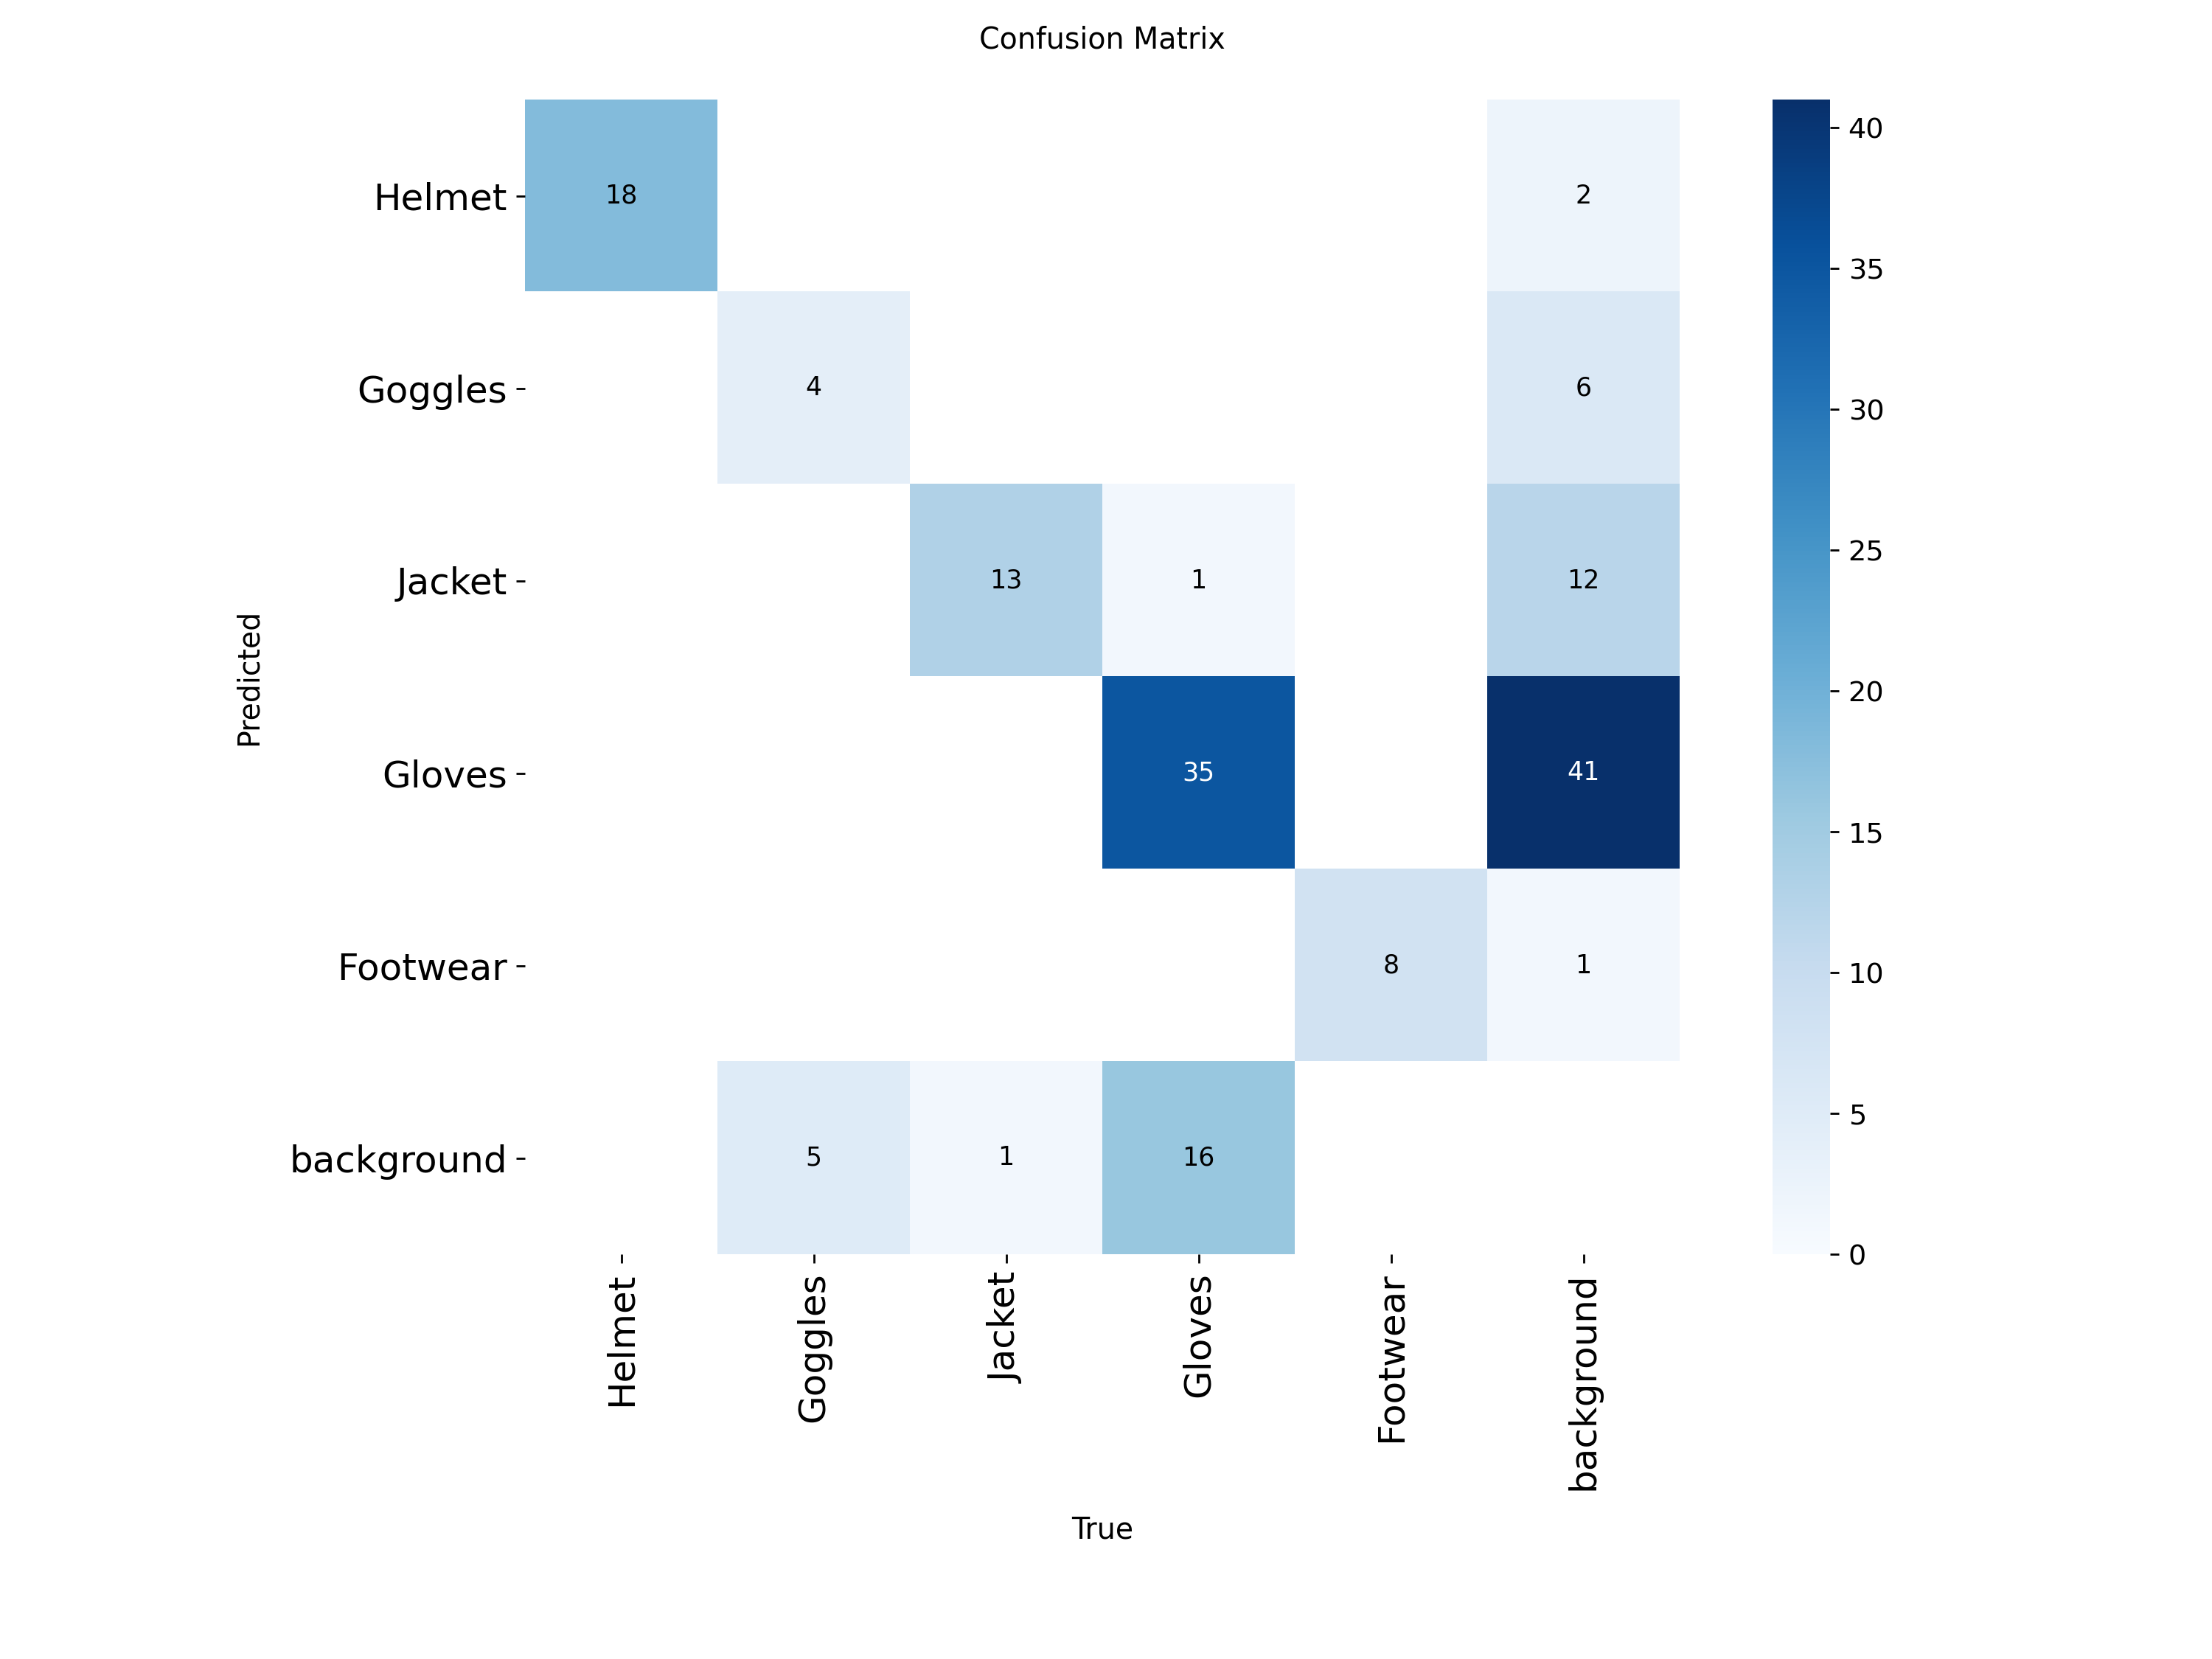

In [26]:
Image(filename='/content/drive/MyDrive/Data/runs/detect/train-2/confusion_matrix.png', width=600)

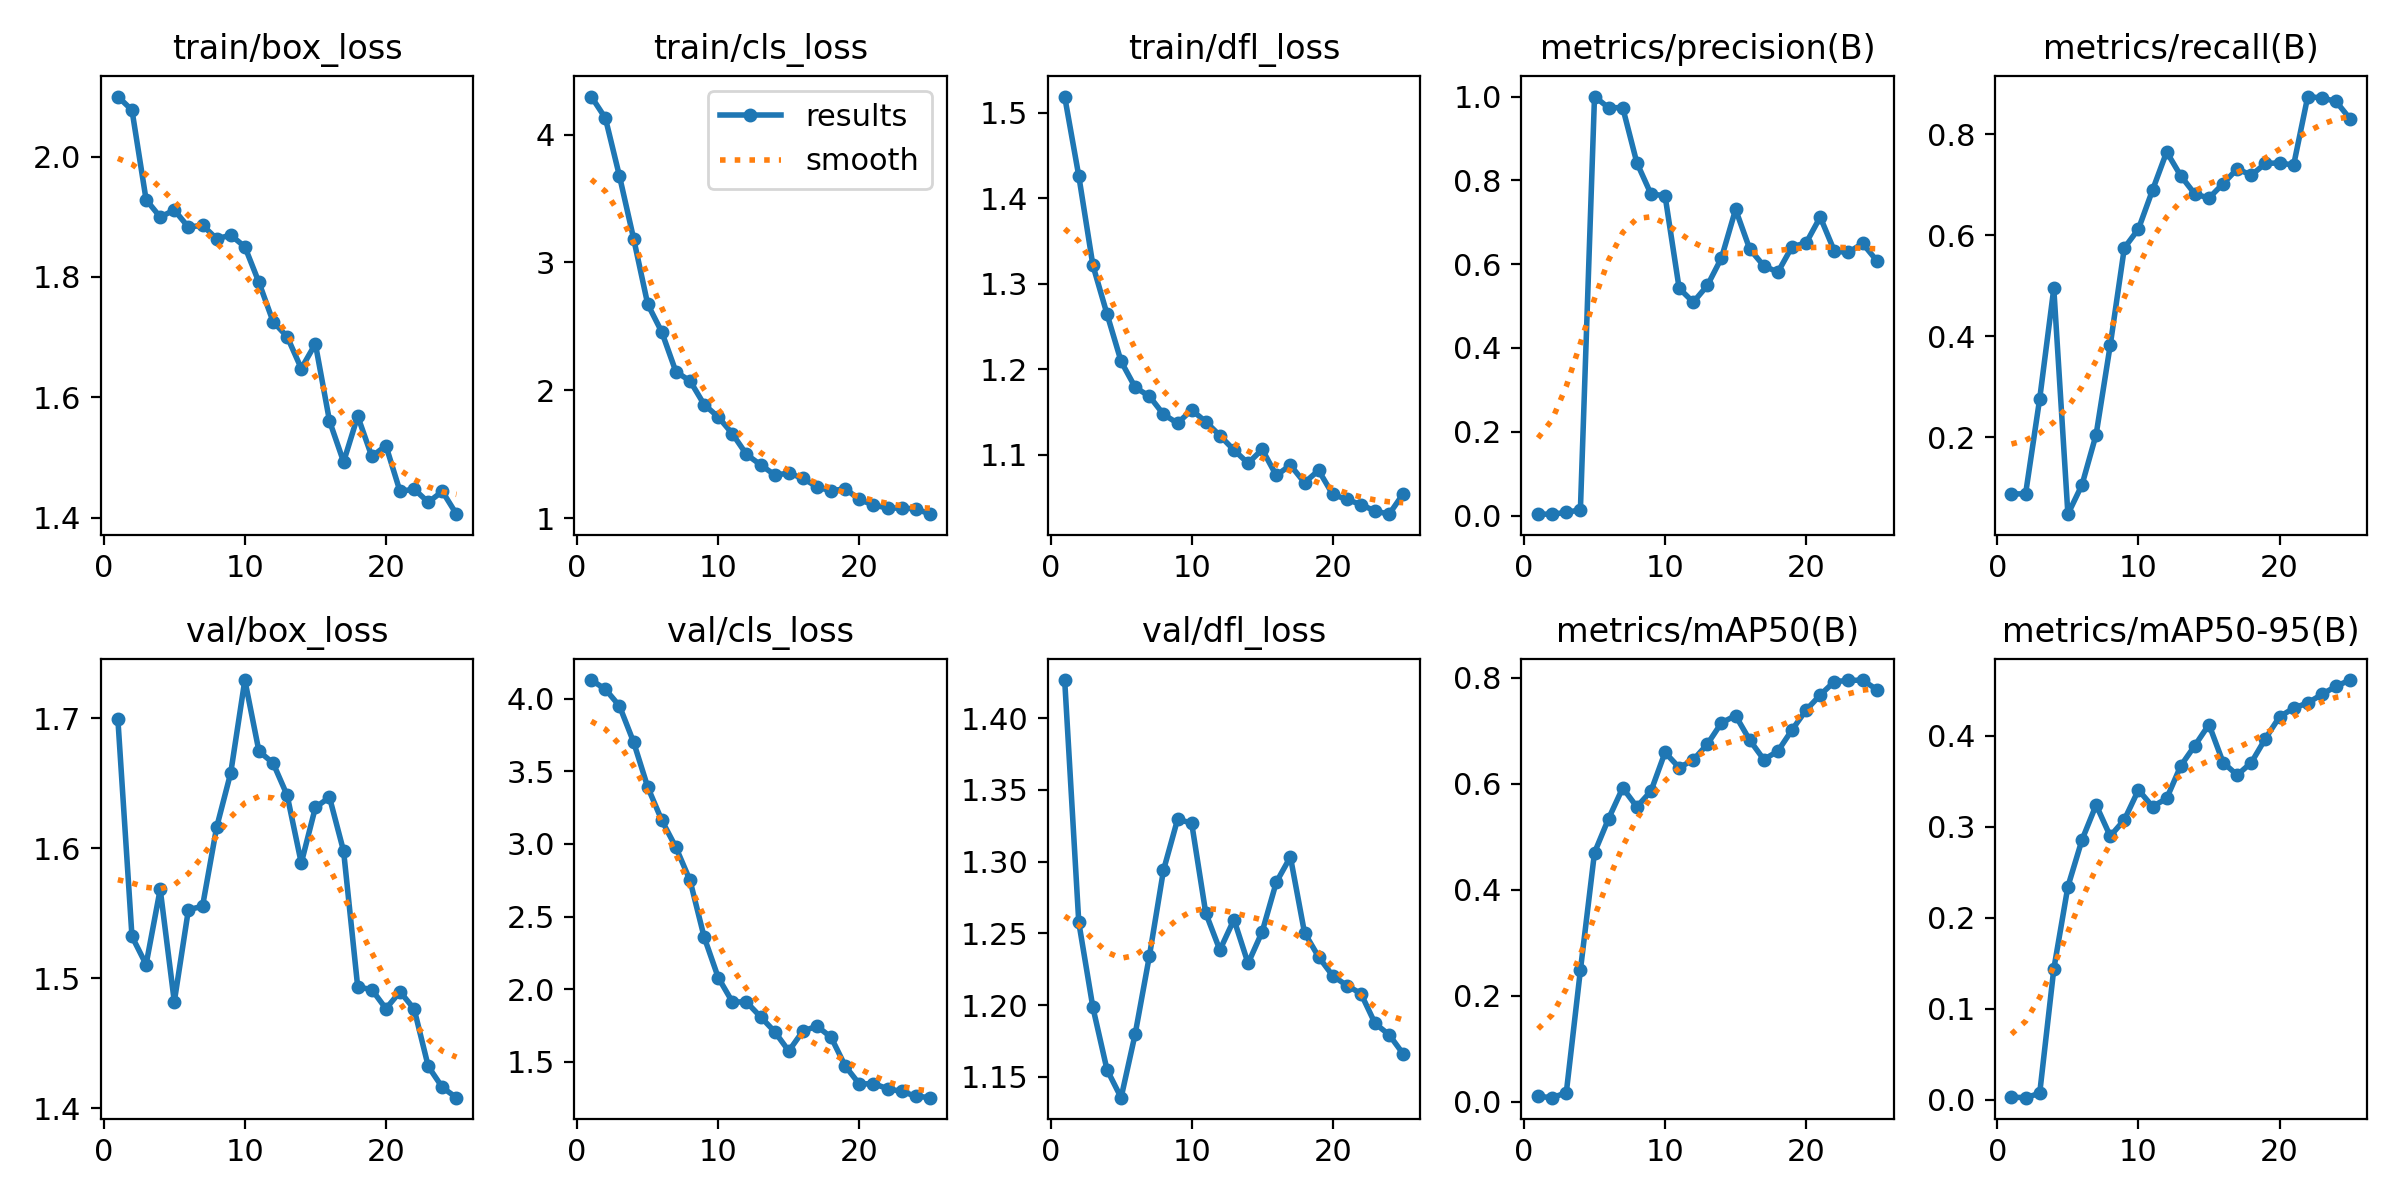

In [27]:
Image(filename='/content/drive/MyDrive/Data/runs/detect/train-2/results.png', width=600)

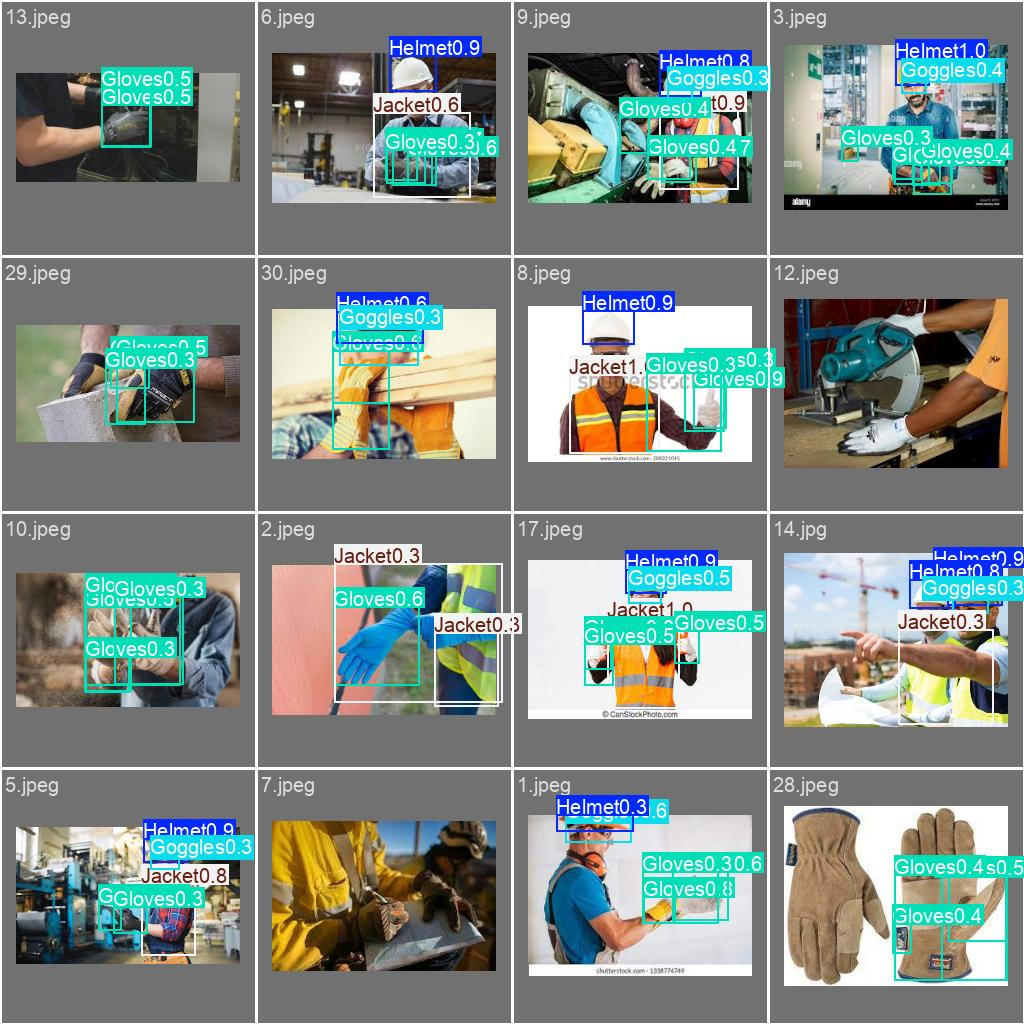

In [28]:
Image(filename='/content/drive/MyDrive/Data/runs/detect/train-2/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [29]:
!yolo task=detect mode=val model="/content/drive/MyDrive/Data/runs/detect/train-2/weights/best.pt" data=data.yaml

Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 3.4±1.4 MB/s, size: 7.6 KB)
val: Scanning /content/drive/MyDrive/Data/valid/labels.cache... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 3.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5it/s 0.8s
                   all         31        101      0.647      0.788      0.772      0.454
                Helmet         17         18      0.881          1      0.995      0.683
               Goggles          9          9        0.5      0.556      0.524       0.26
                Jacket         13         14      0.506      0.857      0.844      0.623
                Gloves         30         52      0.544      0.654      0.607      0.309
              Footwear          4          8      

## Inference with Custom Model

In [30]:
!yolo task = detect mode=predict model = "/content/drive/MyDrive/Data/runs/detect/train-2/weights/best.pt" conf = 0.25 source = "/content/drive/MyDrive/Data/test/images"

Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs

image 1/31 /content/drive/MyDrive/Data/test/images/1.jpeg: 192x224 1 Helmet, 1 Goggles, 3 Glovess, 40.5ms
image 2/31 /content/drive/MyDrive/Data/test/images/10.jpeg: 160x224 4 Glovess, 38.9ms
image 3/31 /content/drive/MyDrive/Data/test/images/11.jpeg: 224x224 2 Glovess, 7.0ms
image 4/31 /content/drive/MyDrive/Data/test/images/12.jpeg: 192x224 (no detections), 6.7ms
image 5/31 /content/drive/MyDrive/Data/test/images/13.jpeg: 128x224 1 Gloves, 45.5ms
image 6/31 /content/drive/MyDrive/Data/test/images/14(1).jpeg: 224x224 2 Jackets, 1 Gloves, 6.4ms
image 7/31 /content/drive/MyDrive/Data/test/images/14.jpg: 192x224 2 Helmets, 1 Goggles, 1 Jacket, 6.5ms
image 8/31 /content/drive/MyDrive/Data/test/images/15.jpeg: 224x224 3 Jackets, 6.1ms
image 9/31 /content/drive/MyDrive/Data/test/images/16.jpeg: 224x160 1 Helmet, 1 Jacket, 1 Glove